<a href="https://colab.research.google.com/github/behraj/journals/blob/main/SSS_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Experiment

In [ ]:
# Load the packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier

In [ ]:
!wget -O creditfraud.zip https://www.dropbox.com/s/tl20yp9bcl56oxt/creditcardfraud.zip?dl=0

--2021-09-02 19:35:59--  https://www.dropbox.com/s/tl20yp9bcl56oxt/creditcardfraud.zip?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/raw/tl20yp9bcl56oxt/creditcardfraud.zip [following]
--2021-09-02 19:36:00--  https://www.dropbox.com/s/raw/tl20yp9bcl56oxt/creditcardfraud.zip
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb3f12c8613101474638b40bdbf.dl.dropboxusercontent.com/cd/0/inline/BVZ3EFHTlKweoEWb1eCrdY7gkg21IPVdgMPqdo0wgjKLkpKq3WAJACrXfyubTF-RRdVBXgpVHKZpK-vPzy6nlgenSwB4u6QZM2HnNCbENUfw18fRwHUelN9vK6lkpAZlQIzFx5eBfvoa29TyaPMdm2Bb/file# [following]
--2021-09-02 19:36:00--  https://ucb3f12c8613101474638b40bdbf.dl.dropboxusercontent.com/cd/0/inline/BVZ3EFHTlKweoEWb1eCrdY7gkg21IPVdgMPqdo0wgjKLkpKq3WAJACrXfyubTF-

In [ ]:
!unzip creditfraud.zip

Archive:  creditfraud.zip
  inflating: creditcard.csv          


In [ ]:
data = pd.read_csv("creditcard.csv")
# Get familiar with the column names
print(data.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [ ]:
# Descriptive Statistics
# print(data.describe())
dataset = data

In [ ]:
X=dataset.drop('Class',axis=1) #Predictors
y=dataset['Class'] #Response
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
Encoder_X = LabelEncoder()
for col in X.columns:
    X[col] = Encoder_X.fit_transform(X[col])
Encoder_y=LabelEncoder()
y = Encoder_y.fit_transform(y)
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0,44928,120599,270851,243083,105668,211710,167150,159663,185803,169841,89285,52456,44135,83003,265234,69684,180407,141540,199265,228524,140442,174834,90634,147486,160454,105171,218749,102230,13502
1,0,190308,160391,134835,182525,151841,161430,120001,155852,112665,125034,262015,251738,190838,106666,206407,198499,129314,110148,113790,132797,68639,54299,190891,72302,168529,179871,126158,142841,268
2,1,44982,28959,251918,175559,87589,253515,227985,194133,20473,184645,197359,128132,210941,103313,274931,1054,256988,119366,1783,251790,223177,233865,269516,36866,68122,117706,81907,61165,23493
3,1,67135,107605,252751,68890,143700,244170,166825,214475,24537,144244,119840,144365,192648,86069,65853,28188,40820,271794,17895,70472,108399,136591,60398,13166,253297,96705,191339,195684,11549
4,2,55018,212082,240745,177861,97922,181139,207795,54735,222386,227847,64399,196504,252494,22796,154747,71701,109484,131978,237769,244940,143568,236625,79502,163439,94807,232984,235552,255032,6905


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [ ]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)

# X_train = pca.fit_transform(X_train)
# X_test = pca.transform(X_test)

## Simple NN-01

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

In [ ]:
classifier.add(Dense(8, kernel_initializer='uniform', activation= 'relu', input_shape=(X_train.shape[-1],)))
classifier.add(Dense(6, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(5, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(4, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(1, kernel_initializer= 'uniform', activation= 'sigmoid'))
classifier.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
classifier.fit(X_train,y_train,batch_size=10,epochs=10)

Epoch 1/10
19937/19937 [==============================] - 32s 2ms/step - loss: 0.0100 - accuracy: 0.9989
Epoch 2/10
19937/19937 [==============================] - 30s 2ms/step - loss: 0.0038 - accuracy: 0.9993
Epoch 3/10
19937/19937 [==============================] - 30s 2ms/step - loss: 0.0035 - accuracy: 0.9993
Epoch 4/10
19937/19937 [==============================] - 30s 1ms/step - loss: 0.0034 - accuracy: 0.9993
Epoch 5/10
19937/19937 [==============================] - 30s 2ms/step - loss: 0.0033 - accuracy: 0.9994
Epoch 6/10
19937/19937 [==============================] - 30s 2ms/step - loss: 0.0032 - accuracy: 0.9994
Epoch 7/10
19937/19937 [==============================] - 30s 2ms/step - loss: 0.0032 - accuracy: 0.9994
Epoch 8/10
19937/19937 [==============================] - 30s 2ms/step - loss: 0.0031 - accuracy: 0.9994
Epoch 9/10
19937/19937 [==============================] - 30s 1ms/step - loss: 0.0031 - accuracy: 0.9994
Epoch 10/10
19937/19937 [==============================

In [ ]:
y_pred=classifier.predict(X_test)
# y_pred=(y_pred>0.5)
score = classifier.evaluate(X_test, y_test)
print(score)

2671/2671 [==============================] - 3s 1ms/step - loss: 0.0032 - accuracy: 0.9993
[0.0031981596257537603, 0.9993211627006531]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def print_score(label, prediction, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, prediction)}\n")

    elif train==False:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Test Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(label, prediction)}\n")

In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print_score(y_train, y_train_pred.round(), train=True)
print_score(y_test, y_test_pred.round(), train=False)

scores_dict = {
    'ANNs': {
        'Train': f1_score(y_train, y_train_pred.round()),
        'Test': f1_score(y_test, y_test_pred.round()),
    },
}

Train Result:
Accuracy Score: 99.94%
_______________________________________________
Classification Report:
                       0           1  accuracy      macro avg   weighted avg
precision       0.999658    0.864865  0.999433       0.932262       0.999418
recall          0.999774    0.808989  0.999433       0.904381       0.999433
f1-score        0.999716    0.835994  0.999433       0.917855       0.999424
support    199008.000000  356.000000  0.999433  199364.000000  199364.000000
_______________________________________________
Confusion Matrix: 
 [[198963     45]
 [    68    288]]

Test Result:
Accuracy Score: 99.93%
_______________________________________________
Classification Report:
                      0           1  accuracy     macro avg  weighted avg
precision      0.999672    0.782609  0.999321      0.891140      0.999326
recall         0.999648    0.794118  0.999321      0.896883      0.999321
f1-score       0.999660    0.788321  0.999321      0.893991      0.999324


#### Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_test_pred.round()))
print("recall Score:\n",recall_score(y_test, y_test_pred.round()))
print("f-Score:\n",f1_score(y_test, y_test_pred.round()))
print("Accuracy Score:\n",accuracy_score(y_test, y_test_pred.round()))
# print("Classification report:\n",classification_report(y_test, y_test_pred))
print("Confusion matrix:\n",confusion_matrix(y_test, y_test_pred.round()))
print("Geometeric mean:\n", geometric_mean_score(y_test, y_test_pred.round()))
print('Roc_auc_score:\n',roc_auc_score(y_test, y_test_pred.round()))
print('Balanced accuracy score:\n', balanced_accuracy_score(y_test, y_test_pred.round()))

Precision Score:
 0.782608695652174
recall Score:
 0.7941176470588235
f-Score:
 0.7883211678832117
Accuracy Score:
 0.9993211848834895
Confusion matrix:
 [[85277    30]
 [   28   108]]
Geometeric mean:
 0.8909760821105799
Roc_auc_score:
 0.8968829880176717


/usr/local/lib/python3.7/dist-packages/sklearn/preprocessing/_label.py:268: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Balanced accuracy score:
 0.8968829880176719


####------ Simple NN-01 Ends Here-----

#Give me Some credit

In [ ]:
# reading the testing file from local drive
from google.colab import files
uploaded = files.upload()

Saving cs-test.csv to cs-test.csv
Saving cs-training.csv to cs-training.csv


In [ ]:
import pandas as pd
df1 = pd.read_csv('cs-training.csv')
df2 = pd.read_csv('cs-test.csv')

In [ ]:
df1.columns= df2.columns
dataset_GMSC= pd.concat([df1, df2 ], axis=0, ignore_index=True)
dataset_GMSC.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1.0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0.0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0.0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0.0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0.0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
dataset_GMSC.drop("Unnamed: 0", axis=1, inplace=True)
ds = dataset_GMSC.dropna()
# dataset_GMSC.isna().sum()
dataset= ds
# dataset.describe()
print(dataset.shape)
# print(ds.shape)
# ds.isnull().sum(axis = 1)

(120269, 11)


In [ ]:
datax = dataset[['RevolvingUtilizationOfUnsecuredLines','age','NumberOfTime30-59DaysPastDueNotWorse','DebtRatio','MonthlyIncome','NumberOfOpenCreditLinesAndLoans','NumberOfTimes90DaysLate','NumberRealEstateLoansOrLines','NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']]
datay = dataset[['SeriousDlqin2yrs']]
datax.shape

(120269, 10)

In [ ]:
frames = [datax, datay]
data_GiveMeSome = pd.concat(frames, axis=1, sort=False)
data_GiveMeSome.shape

(120269, 11)

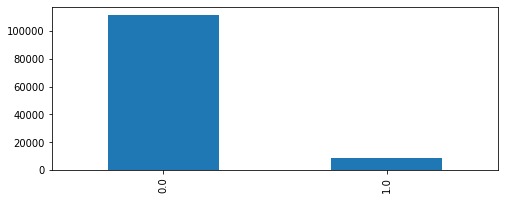

In [ ]:
# label distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
dataset['SeriousDlqin2yrs'].value_counts().plot(kind='bar')

In [ ]:
class0 = dataset['SeriousDlqin2yrs'].value_counts()[0]
class1 = dataset['SeriousDlqin2yrs'].value_counts()[1]
print("class 0 : {}".format(class0))
print("class 1 : {}".format(class1))
print("delinquency rate: {}".format(class1/(class0+class1)))

class 0 : 111912
class 1 : 8357
delinquency rate: 0.06948590243537403


In [ ]:
from sklearn.model_selection import train_test_split
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# X_train,X_test,Y_train,Y_test = train_test_split(datax,datay, test_size=0.2,random_state=0)
X_train_v, X_test, y_train_v, y_test = train_test_split(datax,datay, test_size=0.2,random_state=0)
X_train, X_validate, y_train, y_validate = train_test_split(X_train_v, y_train_v,
                                                            test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

w_p = y_train.value_counts()[0] / len(y_train)
w_n = y_train.value_counts()[1] / len(y_train)

print(f": {w_n}")
print(f": {w_p}")
print(X_train_v.shape)
print(y_train_v.shape)
print(X_test.shape)
print(y_test.shape)

: SeriousDlqin2yrs
1.0                 0.069077
dtype: float64
: SeriousDlqin2yrs
0.0                 0.930923
dtype: float64
(96215, 10)
(96215, 1)
(24054, 10)
(24054, 1)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def print_score(label, prediction, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, prediction)}\n")

    elif train==False:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Test Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(label, prediction)}\n")

In [ ]:
print(f"TRAINING: X_train: {X_train.shape}, y_train: {y_train.shape}\n{'_'*55}")
print(f"VALIDATION: X_validate: {X_validate.shape}, y_validate: {y_validate.shape}\n{'_'*50}")
print(f"TESTING: X_test: {X_test.shape}, y_test: {y_test.shape}")

TRAINING: X_train: (76972, 10), y_train: (76972, 1)
_______________________________________________________
VALIDATION: X_validate: (19243, 10), y_validate: (19243, 1)
__________________________________________________
TESTING: X_test: (24054, 10), y_test: (24054, 1)


In [ ]:
def evaluate(y_test, y_pred):
    # precision true positive / (true positive + false positive)
    # recall: true positive  / (true positive + false ne)
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    # f1 = 2 * (precision * recall) / (precision + recall)
    f1 = f1_score(y_test, y_pred)
    #auc_score = auc(precision, recall)
    return precision, recall, f1

## Simple NN-01

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

In [ ]:
classifier.add(Dense(8, kernel_initializer='uniform', activation= 'relu', input_shape=(X_train.shape[-1],)))
classifier.add(Dense(6, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(5, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(4, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(1, kernel_initializer= 'uniform', activation= 'sigmoid'))
classifier.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
classifier.fit(X_train,y_train,batch_size=10,epochs=10)

Epoch 1/10
7698/7698 [==============================] - 11s 1ms/step - loss: 0.2143 - accuracy: 0.9309
Epoch 2/10
7698/7698 [==============================] - 9s 1ms/step - loss: 0.2005 - accuracy: 0.9330
Epoch 3/10
7698/7698 [==============================] - 10s 1ms/step - loss: 0.1995 - accuracy: 0.9342
Epoch 4/10
7698/7698 [==============================] - 9s 1ms/step - loss: 0.1995 - accuracy: 0.9346
Epoch 5/10
7698/7698 [==============================] - 10s 1ms/step - loss: 0.1992 - accuracy: 0.9343
Epoch 6/10
7698/7698 [==============================] - 10s 1ms/step - loss: 0.1991 - accuracy: 0.9345
Epoch 7/10
7698/7698 [==============================] - 9s 1ms/step - loss: 0.1990 - accuracy: 0.9345
Epoch 8/10
7698/7698 [==============================] - 10s 1ms/step - loss: 0.1989 - accuracy: 0.9347
Epoch 9/10
7698/7698 [==============================] - 9s 1ms/step - loss: 0.1988 - accuracy: 0.9347
Epoch 10/10
7698/7698 [==============================] - 10s 1ms/step - loss:

In [ ]:
y_pred=classifier.predict(X_test)
# y_pred=(y_pred>0.5)
score = classifier.evaluate(X_test, y_test)
print(score)

752/752 [==============================] - 1s 1ms/step - loss: 0.2005 - accuracy: 0.9327
[0.20050287246704102, 0.9327346682548523]


#### Evaluation Metrics

In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print_score(y_train, y_train_pred.round(), train=True)
print_score(y_test, y_test_pred.round(), train=False)

scores_dict = {
    'ANNs': {
        'Train': f1_score(y_train, y_train_pred.round()),
        'Test': f1_score(y_test, y_test_pred.round()),
    },
}

Train Result:
Accuracy Score: 93.47%
_______________________________________________
Classification Report:
                    0.0          1.0  accuracy     macro avg  weighted avg
precision      0.942607     0.585781  0.934717      0.764194      0.917958
recall         0.990161     0.187512  0.934717      0.588836      0.934717
f1-score       0.965799     0.284086  0.934717      0.624942      0.918708
support    71655.000000  5317.000000  0.934717  76972.000000  76972.000000
_______________________________________________
Confusion Matrix: 
 [[70950   705]
 [ 4320   997]]

Test Result:
Accuracy Score: 93.27%
_______________________________________________
Classification Report:
                    0.0          1.0  accuracy     macro avg  weighted avg
precision      0.940849     0.578067  0.932735      0.759458      0.915179
recall         0.989844     0.182726  0.932735      0.586285      0.932735
f1-score       0.964725     0.277679  0.932735      0.621202      0.916111
support   

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_test_pred.round()))
print("recall Score:\n",recall_score(y_test, y_test_pred.round()))
print("f-Score:\n",f1_score(y_test, y_test_pred.round()))
print("Accuracy Score:\n",accuracy_score(y_test, y_test_pred.round()))
# print("Classification report:\n",classification_report(y_test, y_test_pred))
print("Confusion matrix:\n",confusion_matrix(y_test, y_test_pred.round()))
print("Geometeric mean:\n", geometric_mean_score(y_test, y_test_pred.round()))
print('Roc_auc_score:\n',roc_auc_score(y_test, y_test_pred.round()))
print('Balanced accuracy score:\n', balanced_accuracy_score(y_test, y_test_pred.round()))

Precision Score:
 0.5780669144981413
recall Score:
 0.1827262044653349
f-Score:
 0.27767857142857144
Accuracy Score:
 0.9327346803026524
Confusion matrix:
 [[22125   227]
 [ 1391   311]]
Geometeric mean:
 0.42528871797633355
Roc_auc_score:
 0.5862852568497039
Balanced accuracy score:
 0.5862852568497039


/usr/local/lib/python3.7/dist-packages/sklearn/preprocessing/_label.py:268: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


####------ Simple NN-01 Ends Here-----

# Mushroom

In [ ]:
# reading the testing file from local drive
from google.colab import files
uploaded = files.upload()

Saving mushrooms.csv to mushrooms.csv


In [ ]:
dat = pd.read_csv('mushrooms.csv', header=0)
dat.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [ ]:
dataset = dat
dataset.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [ ]:
dataset.shape # 8124 tuples and 23 attributes
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [ ]:
dataset.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
X=dataset.drop('class',axis=1) #Predictors
y=dataset['class'] #Response
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [ ]:
dataset.nunique()

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
Encoder_X = LabelEncoder()
for col in X.columns:
    X[col] = Encoder_X.fit_transform(X[col])
Encoder_y=LabelEncoder()
y = Encoder_y.fit_transform(y)

In [ ]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,3,2,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,2,2,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,2,2,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,3,2,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,3,2,2,7,7,0,2,1,0,3,0,1


In [ ]:
y

array([1, 0, 0, ..., 0, 1, 0])

In [ ]:
X=pd.get_dummies(X,columns=X.columns,drop_first=True)
X.head()

,cap-shape_1,cap-shape_2,cap-shape_3,cap-shape_4,cap-shape_5,cap-surface_1,cap-surface_2,cap-surface_3,cap-color_1,cap-color_2,cap-color_3,cap-color_4,cap-color_5,cap-color_6,cap-color_7,cap-color_8,cap-color_9,bruises_1,odor_1,odor_2,odor_3,odor_4,odor_5,odor_6,odor_7,odor_8,gill-attachment_1,gill-spacing_1,gill-size_1,gill-color_1,gill-color_2,gill-color_3,gill-color_4,gill-color_5,gill-color_6,gill-color_7,gill-color_8,gill-color_9,gill-color_10,gill-color_11,...,stalk-color-above-ring_5,stalk-color-above-ring_6,stalk-color-above-ring_7,stalk-color-above-ring_8,stalk-color-below-ring_1,stalk-color-below-ring_2,stalk-color-below-ring_3,stalk-color-below-ring_4,stalk-color-below-ring_5,stalk-color-below-ring_6,stalk-color-below-ring_7,stalk-color-below-ring_8,veil-color_1,veil-color_2,veil-color_3,ring-number_1,ring-number_2,ring-type_1,ring-type_2,ring-type_3,ring-type_4,spore-print-color_1,spore-print-color_2,spore-print-color_3,spore-print-color_4,spore-print-color_5,spore-print-color_6,spore-print-color_7,spore-print-color_8,population_1,population_2,population_3,population_4,population_5,habitat_1,habitat_2,habitat_3,habitat_4,habitat_5,habitat_6
0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

### Fuctions to visualize test and training

In [ ]:
def visualization_train(model):
    sns.set_context(context='notebook',font_scale=2)
    plt.figure(figsize=(16,9))
    from matplotlib.colors import ListedColormap
    X_set, y_set = X_train, y_train
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.6, cmap = ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c = ListedColormap(('red', 'green'))(i), label = j)
    plt.title("%s Training Set" %(model))
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend()
def visualization_test(model):
    sns.set_context(context='notebook',font_scale=2)
    plt.figure(figsize=(16,9))
    from matplotlib.colors import ListedColormap
    X_set, y_set = X_test, y_test
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                         np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha = 0.6, cmap = ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c = ListedColormap(('red', 'green'))(i), label = j)
    plt.title("%s Test Set" %(model))
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')


## Simple NN-01

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

In [ ]:
X_train.shape

(5686, 2)

In [ ]:
classifier.add(Dense(8, kernel_initializer='uniform', activation= 'relu', input_dim = 2))
classifier.add(Dense(6, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(5, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(4, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(1, kernel_initializer= 'uniform', activation= 'sigmoid'))
classifier.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
classifier.fit(X_train,y_train,batch_size=10,epochs=10)

Epoch 1/10
569/569 [==============================] - 1s 1ms/step - loss: 0.5907 - accuracy: 0.6629
Epoch 2/10
569/569 [==============================] - 1s 1ms/step - loss: 0.3609 - accuracy: 0.8704
Epoch 3/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2757 - accuracy: 0.9045
Epoch 4/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2647 - accuracy: 0.9070
Epoch 5/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2605 - accuracy: 0.9077
Epoch 6/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2576 - accuracy: 0.9073
Epoch 7/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2557 - accuracy: 0.9089
Epoch 8/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2537 - accuracy: 0.9100
Epoch 9/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2519 - accuracy: 0.9119
Epoch 10/10
569/569 [==============================] - 1s 1ms/step - loss: 0.2505 - accuracy: 0.9107

In [ ]:
y_pred=classifier.predict(X_test)
# y_pred=(y_pred>0.5)

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test, y_pred.round()))

[[1239   18]
 [ 199  982]]


In [ ]:
print(classification_report(y_test, y_pred.round()))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1257
           1       0.98      0.83      0.90      1181

    accuracy                           0.91      2438
   macro avg       0.92      0.91      0.91      2438
weighted avg       0.92      0.91      0.91      2438



#### Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_pred.round()))
print("recall Score:\n",recall_score(y_test, y_pred.round()))
print("Accuracy Score:\n",accuracy_score(y_test, y_pred.round()))
# print("Classification report:\n",classification_report(y_test, y_pred))
# print("Confusion matrix:\n",confusion_matrix(y_test, y_pred))
print("Geometeric mean:\n", geometric_mean_score(y_test, y_pred.round()))
# print('Roc_auc_score:\n',roc_auc_score(y_test, y_pred))
print('Balanced accuracy score:\n', balanced_accuracy_score(y_test, y_pred.round()))

Precision Score:
 0.982
recall Score:
 0.8314987298899238
Accuracy Score:
 0.9109926168990976
Geometeric mean:
 0.905313109833613
Balanced accuracy score:
 0.9085894604103557


/usr/local/lib/python3.7/dist-packages/sklearn/preprocessing/_label.py:268: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# visualization_train(model='ANN')

In [ ]:
# visualization_test(model='ANN')

####------ Simple NN-01 Ends Here-----

# PenDigits

In [ ]:
# reading the testing file from local drive
from google.colab import files
uploaded = files.upload()

Saving pendigits.csv to pendigits.csv


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

# url = "creditcard.csv"

df = pd.read_csv('pendigits.csv')
# df = df1.replace(np.nan,0)

df.head()

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [ ]:
print(df.columns.tolist())

['input1', 'input2', 'input3', 'input4', 'input5', 'input6', 'input7', 'input8', 'input9', 'input10', 'input11', 'input12', 'input13', 'input14', 'input15', 'input16', 'class']


In [ ]:
'''import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

colors = ["#808080", "#DF0101",  "#F08080", "#FFFF00", "#000000", "#808000", "#00FFFF", "#0000FF", "#800000","#000080"]

sns.countplot('class', data=df, palette=colors)
# plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)
plt.title('', fontsize=14)'''

'import numpy as np # linear algebra\nimport pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)\nimport tensorflow as tf\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.manifold import TSNE\nfrom sklearn.decomposition import PCA, TruncatedSVD\nimport matplotlib.patches as mpatches\nimport time\n\ncolors = ["#808080", "#DF0101",  "#F08080", "#FFFF00", "#000000", "#808000", "#00FFFF", "#0000FF", "#800000","#000080"]\n\nsns.countplot(\'class\', data=df, palette=colors)\n# plt.title(\'Class Distributions \n (0: No Fraud || 1: Fraud)\', fontsize=14)\nplt.title(\'\', fontsize=14)'

In [ ]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)
from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler is less prone to outliers.

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_input1'] = rob_scaler.fit_transform(df['input1'].values.reshape(-1,1))
df['scaled_input2'] = rob_scaler.fit_transform(df['input2'].values.reshape(-1,1))
df['scaled_input3'] = rob_scaler.fit_transform(df['input3'].values.reshape(-1,1))
df['scaled_input4'] = rob_scaler.fit_transform(df['input4'].values.reshape(-1,1))
df['scaled_input5'] = rob_scaler.fit_transform(df['input5'].values.reshape(-1,1))
df['scaled_input6'] = rob_scaler.fit_transform(df['input6'].values.reshape(-1,1))
df['scaled_input7'] = rob_scaler.fit_transform(df['input7'].values.reshape(-1,1))
df['scaled_input8'] = rob_scaler.fit_transform(df['input8'].values.reshape(-1,1))
df['scaled_input9'] = rob_scaler.fit_transform(df['input9'].values.reshape(-1,1))
df['scaled_input10'] = rob_scaler.fit_transform(df['input10'].values.reshape(-1,1))
df['scaled_input11'] = rob_scaler.fit_transform(df['input11'].values.reshape(-1,1))
df['scaled_input12'] = rob_scaler.fit_transform(df['input12'].values.reshape(-1,1))
df['scaled_input13'] = rob_scaler.fit_transform(df['input13'].values.reshape(-1,1))
df['scaled_input14'] = rob_scaler.fit_transform(df['input14'].values.reshape(-1,1))
df['scaled_input15'] = rob_scaler.fit_transform(df['input15'].values.reshape(-1,1))
df['scaled_input16'] = rob_scaler.fit_transform(df['input16'].values.reshape(-1,1))

df.drop(['input1','input2','input3','input4','input5','input6','input7','input8','input9','input10','input11','input12','input13','input14','input15','input16'], axis=1, inplace=True)

In [ ]:
scaled_input1 = df['scaled_input1']
scaled_input2 = df['scaled_input2']
scaled_input3 = df['scaled_input3']
scaled_input4 = df['scaled_input4']
scaled_input5 = df['scaled_input5']
scaled_input6 = df['scaled_input6']
scaled_input7 = df['scaled_input7']
scaled_input8 = df['scaled_input8']
scaled_input9 = df['scaled_input9']
scaled_input10 = df['scaled_input10']
scaled_input11 = df['scaled_input11']
scaled_input12 = df['scaled_input12']
scaled_input13 = df['scaled_input13']
scaled_input14 = df['scaled_input14']
scaled_input15 = df['scaled_input15']
scaled_input16 = df['scaled_input16']

"""
df.drop(['scaled_input1', 'scaled_input2', 'scaled_input3','scaled_input4','scaled_input5','scaled_input6','scaled_input7','scaled_input8','scaled_input9','scaled_input10','scaled_input11','scaled_input12','scaled_input13','scaled_input14','scaled_input15','scaled_input16'], axis=1, inplace=True)
# df.drop(['scaled_input1', 'scaled_input2','scaled_input3', 'scaled_input4', 'scaled_input5', 'scaled_input6', 'scaled_input7', 'scaled_input8', 'scaled_input9', 'scaled_input10', 'scaled_input11', 'scaled_input12', 'scaled_input13', 'scaled_input14', 'scaled_input15', 'scaled_input16'], axis=1, inplace=True)
df.insert(0, 'scaled_input1', scaled_input1)
df.insert(1, 'scaled_input2', scaled_input2)
df.insert(2, 'scaled_input3', scaled_input3)
df.insert(3, 'scaled_input4', scaled_input4)
df.insert(0, 'scaled_input5', scaled_input5)
df.insert(0, 'scaled_input6', scaled_input6)
df.insert(0, 'scaled_input7', scaled_input7)
df.insert(0, 'scaled_input8', scaled_input8)
df.insert(0, 'scaled_input9', scaled_input9)
df.insert(0, 'scaled_input10', scaled_input10)
df.insert(0, 'scaled_input11', scaled_input11)
df.insert(0, 'scaled_input12', scaled_input12)
df.insert(0, 'scaled_input13', scaled_input13)
df.insert(0, 'scaled_input14', scaled_input14)
df.insert(0, 'scaled_input15', scaled_input15)
df.insert(0, 'scaled_input16', scaled_input16)
"""

# Amount and Time are Scaled!

df.head()

,class,scaled_input1,scaled_input2,scaled_input3,scaled_input4,scaled_input5,scaled_input6,scaled_input7,scaled_input8,scaled_input9,scaled_input10,scaled_input11,scaled_input12,scaled_input13,scaled_input14,scaled_input15,scaled_input16
0,8,0.254237,0.458333,-0.342105,-0.357143,0.066667,-0.918919,-0.597826,-1.048780,-1.000000,-0.212766,-0.229730,0.522727,1.807692,1.500000,0.00,1.745098
1,2,-0.542373,0.000000,-0.342105,0.321429,-0.183333,0.108108,-0.532609,0.048780,-0.750000,-0.382979,-0.486486,-0.681818,0.615385,-0.595238,0.60,-0.058824
2,1,-0.542373,-1.333333,-0.236842,-0.821429,0.316667,0.513514,1.010870,1.390244,0.266667,0.893617,-0.310811,0.477273,-0.961538,-0.047619,-0.24,-0.176471
3,4,-0.542373,0.458333,-0.868421,0.035714,-0.800000,-0.081081,-0.750000,0.048780,0.433333,0.021277,0.364865,0.340909,0.807692,-0.095238,0.27,-0.176471
4,1,-0.542373,-0.916667,0.236842,-0.285714,0.783333,0.783784,0.597826,0.902439,0.000000,0.574468,-0.445946,0.227273,-0.769231,-0.166667,0.07,-0.176471


In [ ]:
dataset = df
# dataset.head()

In [ ]:
X=dataset.drop('class',axis=1) #Predictors
y=dataset['class'] #Response
X.head()

,scaled_input1,scaled_input2,scaled_input3,scaled_input4,scaled_input5,scaled_input6,scaled_input7,scaled_input8,scaled_input9,scaled_input10,scaled_input11,scaled_input12,scaled_input13,scaled_input14,scaled_input15,scaled_input16
0,0.254237,0.458333,-0.342105,-0.357143,0.066667,-0.918919,-0.597826,-1.048780,-1.000000,-0.212766,-0.229730,0.522727,1.807692,1.500000,0.00,1.745098
1,-0.542373,0.000000,-0.342105,0.321429,-0.183333,0.108108,-0.532609,0.048780,-0.750000,-0.382979,-0.486486,-0.681818,0.615385,-0.595238,0.60,-0.058824
2,-0.542373,-1.333333,-0.236842,-0.821429,0.316667,0.513514,1.010870,1.390244,0.266667,0.893617,-0.310811,0.477273,-0.961538,-0.047619,-0.24,-0.176471
3,-0.542373,0.458333,-0.868421,0.035714,-0.800000,-0.081081,-0.750000,0.048780,0.433333,0.021277,0.364865,0.340909,0.807692,-0.095238,0.27,-0.176471
4,-0.542373,-0.916667,0.236842,-0.285714,0.783333,0.783784,0.597826,0.902439,0.000000,0.574468,-0.445946,0.227273,-0.769231,-0.166667,0.07,-0.176471


In [ ]:
y

0        8
1        2
2        1
3        4
4        1
        ..
10987    4
10988    2
10989    0
10990    0
10991    4
Name: class, Length: 10992, dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
Encoder_X = LabelEncoder()
for col in X.columns:
    X[col] = Encoder_X.fit_transform(X[col])
Encoder_y=LabelEncoder()
y = Encoder_y.fit_transform(y)

In [ ]:
X.head()

,scaled_input1,scaled_input2,scaled_input3,scaled_input4,scaled_input5,scaled_input6,scaled_input7,scaled_input8,scaled_input9,scaled_input10,scaled_input11,scaled_input12,scaled_input13,scaled_input14,scaled_input15,scaled_input16
0,47,95,27,78,57,37,26,0,0,23,56,53,100,90,40,98
1,0,84,27,97,42,75,29,45,15,15,37,0,69,2,100,6
2,0,52,31,65,72,90,100,100,76,75,50,51,28,25,16,0
3,0,95,7,89,5,68,19,45,86,34,100,45,74,23,67,0
4,0,62,49,80,100,100,81,80,60,60,40,40,33,20,47,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# print('0', round(df['class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
# print('1', round(df['class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

for i in range (0,10):
  print(i, round(df['class'].value_counts()[i]/len(df) * 100,2), '% of the dataset')


X = df.drop('class', axis=1)
y = df['class']
print(X)
print(y)

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# We already have X_train and y_train for undersample data thats why I am using original to distinguish and to not overwrite these variables.
# original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the Distribution of the labels


# Turn into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

0 10.4 % of the dataset
1 10.4 % of the dataset
2 10.41 % of the dataset
3 9.6 % of the dataset
4 10.41 % of the dataset
5 9.6 % of the dataset
6 9.61 % of the dataset
7 10.39 % of the dataset
8 9.6 % of the dataset
9 9.6 % of the dataset
       scaled_input1  scaled_input2  ...  scaled_input15  scaled_input16
0           0.254237       0.458333  ...            0.00        1.745098
1          -0.542373       0.000000  ...            0.60       -0.058824
2          -0.542373      -1.333333  ...           -0.24       -0.176471
3          -0.542373       0.458333  ...            0.27       -0.176471
4          -0.542373      -0.916667  ...            0.07       -0.176471
...              ...            ...  ...             ...             ...
10987       0.067797       0.458333  ...            0.60       -0.176471
10988      -0.271186      -0.583333  ...            0.60        0.098039
10989       0.406780       0.458333  ...           -0.02        1.647059
10990      -0.220339       0.45

In [ ]:
# Our data is already scaled we should split our training and test sets
from sklearn.model_selection import train_test_split

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train,
                                                            test_size=0.2, random_state=42)

In [ ]:
w_0 = y_train.value_counts()[0] / len(y_train)
w_1 = y_train.value_counts()[1] / len(y_train)
w_2 = y_train.value_counts()[2] / len(y_train)
w_3 = y_train.value_counts()[3] / len(y_train)
w_4 = y_train.value_counts()[4] / len(y_train)
w_5 = y_train.value_counts()[5] / len(y_train)
w_6 = y_train.value_counts()[6] / len(y_train)
w_7 = y_train.value_counts()[7] / len(y_train)
w_8 = y_train.value_counts()[8] / len(y_train)
w_9 = y_train.value_counts()[9] / len(y_train)
print(f"Class: {w_0}")
print(f"class: {w_1}")
print(f"class: {w_2}")
print(f"Class: {w_3}")
print(f"class: {w_4}")
print(f"class: {w_5}")
print(f"Class: {w_6}")
print(f"class: {w_7}")
print(f"class: {w_8}")
print(f"class: {w_9}")

Class: 0.10154346060113728
class: 0.10722989439480098
class: 0.10316815597075549
Class: 0.09179528838342811
class: 0.10722989439480098
class: 0.0934199837530463
Class: 0.09780666125101543
class: 0.10625507717303005
class: 0.09634443541835906
class: 0.09520714865962632


## Simple NN-01

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
classifier = Sequential()
X_train.shape

(7694, 16)

In [ ]:
classifier.add(Dense(8, kernel_initializer='uniform', activation= 'relu', input_shape=(X_train.shape[-1],)))
classifier.add(Dense(6, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(5, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(4, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(1, kernel_initializer= 'uniform', activation= 'sigmoid'))
classifier.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
classifier.fit(X_train,y_train,batch_size=10,epochs=10)

Epoch 1/10
770/770 [==============================] - 2s 1ms/step - loss: -0.7390 - accuracy: 0.1051
Epoch 2/10
770/770 [==============================] - 1s 1ms/step - loss: -3.5050 - accuracy: 0.1050
Epoch 3/10
770/770 [==============================] - 1s 1ms/step - loss: -6.1440 - accuracy: 0.1050
Epoch 4/10
770/770 [==============================] - 1s 2ms/step - loss: -8.7188 - accuracy: 0.1050
Epoch 5/10
770/770 [==============================] - 1s 1ms/step - loss: -11.2676 - accuracy: 0.1050
Epoch 6/10
770/770 [==============================] - 1s 1ms/step - loss: -13.8110 - accuracy: 0.1050
Epoch 7/10
770/770 [==============================] - 1s 1ms/step - loss: -16.3589 - accuracy: 0.1050
Epoch 8/10
770/770 [==============================] - 1s 1ms/step - loss: -18.9126 - accuracy: 0.1050
Epoch 9/10
770/770 [==============================] - 1s 1ms/step - loss: -21.4622 - accuracy: 0.1050
Epoch 10/10
770/770 [==============================] - 1s 1ms/step - loss: -24.0137 - 

In [ ]:
y_pred=classifier.predict(X_test)
# y_pred=(y_pred>0.5)
score = classifier.evaluate(X_test, y_test)
print(score)

104/104 [==============================] - 0s 1ms/step - loss: -25.2398 - accuracy: 0.1016
[-25.239831924438477, 0.10157671570777893]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def print_score(label, prediction, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, prediction)}\n")

    elif train==False:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Test Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(label, prediction)}\n")

In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print_score(y_train, y_train_pred.round(), train=True)
print_score(y_test, y_test_pred.round(), train=False)

scores_dict = {
    'ANNs': {
        'Train': f1_score(y_train, y_train_pred.round(), average = 'micro'),
        'Test': f1_score(y_test, y_test_pred.round(),average = 'micro'),
    },
}

Train Result:
Accuracy Score: 10.50%
_______________________________________________
Classification Report:
               0           1      2  ...  accuracy    macro avg  weighted avg
precision    0.0    0.105017    0.0  ...  0.105017     0.010502      0.011029
recall       0.0    1.000000    0.0  ...  0.105017     0.100000      0.105017
f1-score     0.0    0.190073    0.0  ...  0.105017     0.019007      0.019961
support    789.0  808.000000  813.0  ...  0.105017  7694.000000   7694.000000

[4 rows x 13 columns]
_______________________________________________
Confusion Matrix: 
 [[  0 789   0   0   0   0   0   0   0   0]
 [  0 808   0   0   0   0   0   0   0   0]
 [  0 813   0   0   0   0   0   0   0   0]
 [  0 711   0   0   0   0   0   0   0   0]
 [  0 803   0   0   0   0   0   0   0   0]
 [  0 737   0   0   0   0   0   0   0   0]
 [  0 755   0   0   0   0   0   0   0   0]
 [  0 822   0   0   0   0   0   0   0   0]
 [  0 739   0   0   0   0   0   0   0   0]
 [  0 717   0   0   0   

#### Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_test_pred.round(), average = 'micro'))
print("f-Score:\n",f1_score(y_test, y_test_pred.round(), average = 'micro'))
print("Accuracy Score:\n",accuracy_score(y_test, y_test_pred.round()))
# print("Classification report:\n",classification_report(y_test, y_test_pred))
# print("Confusion matrix:\n",confusion_matrix(y_test, y_test_pred.round(), average = 'micro'))
print("Geometeric mean:\n", geometric_mean_score(y_test, y_test_pred.round()))
# print('Roc_auc_score:\n',roc_auc_score(y_test, y_test_pred.round()))
print('Balanced accuracy score:\n', balanced_accuracy_score(y_test, y_test_pred.round()))

Precision Score:
 0.1015767131594906
f-Score:
 0.10157671315949061
Accuracy Score:
 0.1015767131594906
Geometeric mean:
 0.0
Balanced accuracy score:
 0.1


####------ Simple NN-01 Ends Here-----

## Simple NN

In [ ]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[-1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
])

model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_20 (Dense)             (None, 256)               4352      
_________________________________________________________________
batch_normalization_15 (Batc (None, 256)               1024      
_________________________________________________________________
dropout_15 (Dropout)         (None, 256)               0         
_________________________________________________________________
dense_21 (Dense)             (None, 256)               65792     
_________________________________________________________________
batch_normalization_16 (Batc (None, 256)               1024      
_________________________________________________________________
dropout_16 (Dropout)         (None, 256)               0         
_________________________________________________________________
dense_22 (Dense)             (None, 256)              

In [ ]:
METRICS = [
#     keras.metrics.Accuracy(name='accuracy'),
    keras.metrics.FalseNegatives(name='fn'),
    keras.metrics.FalsePositives(name='fp'),
    keras.metrics.TrueNegatives(name='tn'),
    keras.metrics.TruePositives(name='tp'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall')
]

model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=METRICS)

callbacks = [keras.callbacks.ModelCheckpoint('fraud_model_at_epoch_{epoch}.h5')]
class_weight = {0:w_p, 1:w_n}

r = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    # batch_size=2048,
    epochs=10,
#     class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/10
193/193 [==============================] - 4s 10ms/step - loss: -100.3320 - fn: 2403.0000 - fp: 50.0000 - tn: 575.0000 - tp: 3127.0000 - precision: 0.9843 - recall: 0.5655 - val_loss: -120.6327 - val_fn: 626.0000 - val_fp: 2.0000 - val_tn: 162.0000 - val_tp: 749.0000 - val_precision: 0.9973 - val_recall: 0.5447
Epoch 2/10
193/193 [==============================] - 1s 5ms/step - loss: -480.1284 - fn: 2192.0000 - fp: 17.0000 - tn: 608.0000 - tp: 3338.0000 - precision: 0.9949 - recall: 0.6036 - val_loss: -671.0342 - val_fn: 456.0000 - val_fp: 0.0000e+00 - val_tn: 164.0000 - val_tp: 919.0000 - val_precision: 1.0000 - val_recall: 0.6684
Epoch 3/10
193/193 [==============================] - 1s 5ms/step - loss: -1134.4026 - fn: 1884.0000 - fp: 13.0000 - tn: 612.0000 - tp: 3646.0000 - precision: 0.9964 - recall: 0.6593 - val_loss: -1563.4348 - val_fn: 426.0000 - val_fp: 1.0000 - val_tn: 163.0000 - val_tp: 949.0000 - val_precision: 0.9989 - val_recall: 0.6902
Epoch 4/10
193/193 [====

In [ ]:
score = model.evaluate(X_test, y_test)
print(score)

104/104 [==============================] - 0s 2ms/step - loss: -14211.6328 - fn: 635.0000 - fp: 2.0000 - tn: 352.0000 - tp: 2309.0000 - precision: 0.9991 - recall: 0.7843
[-14211.6328125, 635.0, 2.0, 352.0, 2309.0, 0.9991346001625061, 0.784307062625885]


In [ ]:
preds = model.predict(X_validate)

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print_score(y_train, y_train_pred.round(), train=True)
print_score(y_test, y_test_pred.round(), train=False)

scores_dict = {
    'ANNs': {
        'Train': f1_score(y_train, y_train_pred.round(), average='micro'),
        'Test': f1_score(y_test, y_test_pred.round(), average='micro') ,
    },
}

Train Result:
Accuracy Score: 10.46%
_______________________________________________
Classification Report:
                    0           1      2  ...  accuracy    macro avg  weighted avg
precision    0.334951    0.005348    0.0  ...   0.10463     0.034030      0.034586
recall       0.993600    0.034848    0.0  ...   0.10463     0.102845      0.104630
f1-score     0.501008    0.009272    0.0  ...   0.10463     0.051028      0.051868
support    625.000000  660.000000  635.0  ...   0.10463  6155.000000   6155.000000

[4 rows x 13 columns]
_______________________________________________
Confusion Matrix: 
 [[621   4   0   0   0   0   0   0   0   0]
 [637  23   0   0   0   0   0   0   0   0]
 [592  43   0   0   0   0   0   0   0   0]
 [  4 561   0   0   0   0   0   0   0   0]
 [  0 660   0   0   0   0   0   0   0   0]
 [  0 575   0   0   0   0   0   0   0   0]
 [  0 602   0   0   0   0   0   0   0   0]
 [  0 654   0   0   0   0   0   0   0   0]
 [  0 593   0   0   0   0   0   0   0   0]

In [ ]:

from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_test_pred.round(), average='micro'))
print("Recall Score:\n",recall_score(y_test, y_test_pred.round(), average='micro'))
print("Accuracy Score:\n",accuracy_score(y_test, y_test_pred.round()))
print("geometric_mean_score:\n",geometric_mean_score(y_test, y_test_pred.round(), average='micro'))
print("balanced_accuracy_score:\n",balanced_accuracy_score(y_test, y_test_pred.round()))


Precision Score:
 0.11188599151000607
Recall Score:
 0.11188599151000607
Accuracy Score:
 0.11188599151000607
geometric_mean_score:
 0.31756126393644735
balanced_accuracy_score:
 0.10450965511425922


# Adult

In [ ]:
# reading the testing file from local drive
from google.colab import files
uploaded = files.upload()

Saving adult.csv to adult.csv


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

# url = "creditcard.csv"

df = pd.read_csv('adult.csv')
# df = df1.replace(np.nan,0)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df['workclass']=df['workclass'].replace('?',np.nan)
df['occupation']=df['occupation'].replace('?',np.nan)
df['native-country']=df['native-country'].replace('?',np.nan)


In [ ]:
df = df.drop(['educational-num', 'capital-gain', 'capital-loss'], axis=1 )

In [ ]:
df.describe()

,age,fnlwgt,hours-per-week
count,48842.000000,4.884200e+04,48842.000000
mean,38.643585,1.896641e+05,40.422382
std,13.710510,1.056040e+05,12.391444
min,17.000000,1.228500e+04,1.000000
25%,28.000000,1.175505e+05,40.000000
50%,37.000000,1.781445e+05,40.000000
75%,48.000000,2.376420e+05,45.000000
max,90.000000,1.490400e+06,99.000000


In [ ]:
df.replace(['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent','Never-married','Separated','Widowed'],
             ['divorced','married','married','married','not married','not married','not married'], inplace = True)

In [ ]:
X=df.drop('income',axis=1) #Predictors
y=df['income'] #Response
X.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country
0,25,Private,226802,11th,not married,Machine-op-inspct,Own-child,Black,Male,40,United-States
1,38,Private,89814,HS-grad,married,Farming-fishing,Husband,White,Male,50,United-States
2,28,Local-gov,336951,Assoc-acdm,married,Protective-serv,Husband,White,Male,40,United-States
3,44,Private,160323,Some-college,married,Machine-op-inspct,Husband,Black,Male,40,United-States
4,18,NaN,103497,Some-college,not married,NaN,Own-child,White,Female,30,United-States


In [ ]:
from sklearn import model_selection, preprocessing, metrics
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
labelEncoder = preprocessing.LabelEncoder()
category_col =['race','marital-status', 'gender', 'income']

for col in category_col:
    df[col] = labelEncoder.fit_transform(df[col])

category_col_1 =['workclass', 'education', 'occupation',
               'relationship','native-country']
df_2 = pd.get_dummies(df, columns=category_col_1, drop_first=True)

##unknown Attribute is removed and income class label is appended in the end
dataframe=df_2.drop('fnlwgt',1)
dataframe =dataframe[[c for c in dataframe if c not in ['income']] + ['income']]
dataframe.head(20)

,age,marital-status,race,gender,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,...,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,25,2,2,1,40,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,38,1,4,1,50,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,28,1,4,1,40,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,44,1,2,1,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,18,2,4,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,34,2,4,1,30,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
6,29,2,2,1,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
7,63,1,4,1,32,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
8,24,2,4,0,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
9,55,1,4,1,10,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
X=dataframe.drop('income',axis=1) #Predictors
y=dataframe['income'] #Response
X.head()

,age,marital-status,race,gender,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,...,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,2,2,1,40,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,38,1,4,1,50,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,28,1,4,1,40,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,44,1,2,1,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,18,2,4,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
Encoder_X = LabelEncoder()
for col in X.columns:
    X[col] = Encoder_X.fit_transform(X[col])
Encoder_y=LabelEncoder()
y = Encoder_y.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn import model_selection, preprocessing, metrics
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
labelEncoder = preprocessing.LabelEncoder()
category_col =['race','marital-status', 'gender', 'income']

for col in category_col:
    df[col] = labelEncoder.fit_transform(df[col])

category_col_1 =['workclass', 'education', 'occupation',
               'relationship','native-country']
df_2 = pd.get_dummies(df, columns=category_col_1, drop_first=True)

##unknown Attribute is removed and income class label is appended in the end
dataframe=df_2.drop('fnlwgt',1)
dataframe =dataframe[[c for c in dataframe if c not in ['income']] + ['income']]
dataframe.head(20)

,age,marital-status,race,gender,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,...,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,25,2,2,1,40,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,38,1,4,1,50,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,28,1,4,1,40,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,44,1,2,1,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,18,2,4,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,34,2,4,1,30,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
6,29,2,2,1,40,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
7,63,1,4,1,32,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
8,24,2,4,0,40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
9,55,1,4,1,10,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Simple NN-01

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

In [ ]:
classifier.add(Dense(8, kernel_initializer='uniform', activation= 'relu', input_shape=(X_train.shape[-1],)))
classifier.add(Dense(6, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(5, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(4, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(1, kernel_initializer= 'uniform', activation= 'sigmoid'))
classifier.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
classifier.fit(X_train,y_train,batch_size=10,epochs=10)

Epoch 1/10
3419/3419 [==============================] - 6s 2ms/step - loss: 0.4058 - accuracy: 0.7925
Epoch 2/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3754 - accuracy: 0.8165
Epoch 3/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3695 - accuracy: 0.8204
Epoch 4/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3653 - accuracy: 0.8235
Epoch 5/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3618 - accuracy: 0.8266
Epoch 6/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3607 - accuracy: 0.8264
Epoch 7/10
3419/3419 [==============================] - 6s 2ms/step - loss: 0.3593 - accuracy: 0.8281
Epoch 8/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3581 - accuracy: 0.8286
Epoch 9/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.3560 - accuracy: 0.8304
Epoch 10/10
3419/3419 [==============================] - 5s 2ms/step - loss: 0.354

In [ ]:
y_pred=classifier.predict(X_test)
# y_pred=(y_pred>0.5)
score = classifier.evaluate(X_test, y_test)
print(score)

458/458 [==============================] - 1s 1ms/step - loss: 0.3513 - accuracy: 0.8369
[0.3512571156024933, 0.8368934392929077]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def print_score(label, prediction, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, prediction)}\n")

    elif train==False:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Test Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(label, prediction)}\n")

In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print_score(y_train, y_train_pred.round(), train=True)
print_score(y_test, y_test_pred.round(), train=False)

scores_dict = {
    'ANNs': {
        'Train': f1_score(y_train, y_train_pred.round(), average = 'micro'),
        'Test': f1_score(y_test, y_test_pred.round(),average = 'micro'),
    },
}

Train Result:
Accuracy Score: 83.20%
_______________________________________________
Classification Report:
                      0            1  accuracy     macro avg  weighted avg
precision      0.884347     0.658982  0.832022      0.771665      0.829853
recall         0.895571     0.632757  0.832022      0.764164      0.832022
f1-score       0.889924     0.645603  0.832022      0.767764      0.830846
support    25922.000000  8267.000000  0.832022  34189.000000  34189.000000
_______________________________________________
Confusion Matrix: 
 [[23215  2707]
 [ 3036  5231]]

Test Result:
Accuracy Score: 83.69%
_______________________________________________
Classification Report:
                      0            1  accuracy     macro avg  weighted avg
precision      0.891456     0.653365  0.836893      0.772411      0.835886
recall         0.896377     0.641520  0.836893      0.768949      0.836893
f1-score       0.893910     0.647389  0.836893      0.770649      0.836372
support   

#### Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_test_pred.round(), average = 'micro'))
print("f-Score:\n",f1_score(y_test, y_test_pred.round(), average = 'micro'))
print("recall-Score:\n",recall_score(y_test, y_test_pred.round(), average = 'micro'))
print("Accuracy Score:\n",accuracy_score(y_test, y_test_pred.round()))
# print("Classification report:\n",classification_report(y_test, y_test_pred))
# print("Confusion matrix:\n",confusion_matrix(y_test, y_test_pred.round(), average = 'micro'))
print("Geometeric mean:\n", geometric_mean_score(y_test, y_test_pred.round()))
print('Roc_auc_score:\n',roc_auc_score(y_test, y_test_pred.round()))
print('Balanced accuracy score:\n', balanced_accuracy_score(y_test, y_test_pred.round()))

Precision Score:
 0.8368934689142156
f-Score:
 0.8368934689142156
recall-Score:
 0.8368934689142156
Accuracy Score:
 0.8368934689142156
Geometeric mean:
 0.7583165764686804
Roc_auc_score:
 0.7689486074603702
Balanced accuracy score:
 0.7689486074603702


####------ Simple NN-01 Ends Here-----

# Eye Movement

In [ ]:
# reading the testing file from local drive
from google.colab import files
uploaded = files.upload()

Saving eeg-eye-state.csv to eeg-eye-state.csv


In [ ]:
df = pd.read_csv('eeg-eye-state.csv')
# df = df1.replace(np.nan,0)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,Class
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,1
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,1
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,1
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,1
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,1


In [ ]:
X=df.drop('Class',axis=1) #Predictors
y=df['Class'] #Response
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
Encoder_X = LabelEncoder()
for col in X.columns:
    X[col] = Encoder_X.fit_transform(X[col])
Encoder_y=LabelEncoder()
y = Encoder_y.fit_transform(y)
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14
0,252,179,166,164,83,38,139,138,135,141,199,132,308,320
1,243,170,175,165,67,39,140,134,113,118,192,130,302,301
2,249,174,178,180,57,33,139,117,107,109,190,135,294,311
3,251,184,180,179,70,31,140,118,126,135,198,146,301,325
4,246,184,172,170,78,39,137,112,113,152,202,147,302,329


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


### Simple NN-01

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

In [ ]:
classifier.add(Dense(8, kernel_initializer='uniform', activation= 'relu', input_shape=(X_train.shape[-1],)))
classifier.add(Dense(6, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(5, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(4, kernel_initializer='uniform', activation= 'relu'))
classifier.add(Dense(1, kernel_initializer= 'uniform', activation= 'sigmoid'))
classifier.compile(optimizer= 'adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
classifier.fit(X_train,y_train,batch_size=10,epochs=10)

Epoch 1/10
1049/1049 [==============================] - 2s 1ms/step - loss: 0.2608 - accuracy: 0.5593
Epoch 2/10
1049/1049 [==============================] - 1s 1ms/step - loss: -0.4077 - accuracy: 0.5599
Epoch 3/10
1049/1049 [==============================] - 1s 1ms/step - loss: -0.9135 - accuracy: 0.5599
Epoch 4/10
1049/1049 [==============================] - 1s 1ms/step - loss: -1.3573 - accuracy: 0.5599
Epoch 5/10
1049/1049 [==============================] - 1s 1ms/step - loss: -1.7826 - accuracy: 0.5599
Epoch 6/10
1049/1049 [==============================] - 1s 1ms/step - loss: -2.2061 - accuracy: 0.5599
Epoch 7/10
1049/1049 [==============================] - 1s 1ms/step - loss: -2.6328 - accuracy: 0.5599
Epoch 8/10
1049/1049 [==============================] - 1s 1ms/step - loss: -3.0639 - accuracy: 0.5599
Epoch 9/10
1049/1049 [==============================] - 1s 1ms/step - loss: -3.4968 - accuracy: 0.5599
Epoch 10/10
1049/1049 [==============================] - 1s 1ms/step - los

In [ ]:
y_pred=classifier.predict(X_test)
# y_pred=(y_pred>0.5)
score = classifier.evaluate(X_test, y_test)
print(score)

141/141 [==============================] - 0s 1ms/step - loss: -4.4191 - accuracy: 0.5309
[-4.419132232666016, 0.5309301018714905]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def print_score(label, prediction, train=True):
    if train:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Train Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, prediction)}\n")

    elif train==False:
        clf_report = pd.DataFrame(classification_report(label, prediction, output_dict=True))
        print("Test Result:\n================================================")
        print(f"Accuracy Score: {accuracy_score(label, prediction) * 100:.2f}%")
        print("_______________________________________________")
        print(f"Classification Report:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(label, prediction)}\n")

In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print_score(y_train, y_train_pred.round(), train=True)
print_score(y_test, y_test_pred.round(), train=False)

scores_dict = {
    'ANNs': {
        'Train': f1_score(y_train, y_train_pred.round(), average = 'micro'),
        'Test': f1_score(y_test, y_test_pred.round(),average = 'micro'),
    },
}

Train Result:
Accuracy Score: 55.99%
_______________________________________________
Classification Report:
                     1       2  accuracy     macro avg  weighted avg
precision     0.559889     0.0  0.559889      0.279945      0.313476
recall        1.000000     0.0  0.559889      0.500000      0.559889
f1-score      0.717858     0.0  0.559889      0.358929      0.401921
support    5871.000000  4615.0  0.559889  10486.000000  10486.000000
_______________________________________________
Confusion Matrix: 
 [[5871    0]
 [4615    0]]

Test Result:
Accuracy Score: 53.09%
_______________________________________________
Classification Report:
                     1       2  accuracy    macro avg  weighted avg
precision     0.530930     0.0   0.53093     0.265465      0.281887
recall        1.000000     0.0   0.53093     0.500000      0.530930
f1-score      0.693605     0.0   0.53093     0.346802      0.368256
support    2386.000000  2108.0   0.53093  4494.000000   4494.000000
____

#### Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
print("Precision Score:\n",precision_score(y_test, y_test_pred.round(), average = 'micro'))
print("f-Score:\n",f1_score(y_test, y_test_pred.round(), average = 'micro'))
print("recall-Score:\n",recall_score(y_test, y_test_pred.round(), average = 'micro'))
print("Accuracy Score:\n",accuracy_score(y_test, y_test_pred.round()))
# print("Classification report:\n",classification_report(y_test, y_test_pred))
# print("Confusion matrix:\n",confusion_matrix(y_test, y_test_pred.round(), average = 'micro'))
print("Geometeric mean:\n", geometric_mean_score(y_test, y_test_pred.round()))
print('Roc_auc_score:\n',roc_auc_score(y_test, y_test_pred.round()))
print('Balanced accuracy score:\n', balanced_accuracy_score(y_test, y_test_pred.round()))

Precision Score:
 0.5309301290609701
f-Score:
 0.5309301290609701
recall-Score:
 0.5309301290609701
Accuracy Score:
 0.5309301290609701
Geometeric mean:
 0.0
Roc_auc_score:
 0.5
Balanced accuracy score:
 0.5


####------ Simple NN-01 Ends Here-----

In [ ]:
####------ Simple NN-01 Ends Here-----